# Machine Learning Approach for Internet Usage Segmentation (KMeans Clustering)

# Problem Statement
The objective of this project is to analyze internet usage data and identify distinct groups of users based on their usage patterns. Clustering techniques are applied to uncover hidden structures in the data, enabling better understanding of user behavior and supporting effective decision-making for service providers.


# 📈 Workflow Architecture

# 📊 Data Structure


# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix,classification_report, silhouette_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=(8,3) #(width,heigth)
plt.rcParams['figure.dpi']=150 #pixil
sns.set_theme(style='darkgrid',palette='viridis')

# Load File

In [ ]:
df=pd.read_csv("internet_usage (1).csv")
df

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,AFG,..,0.00472257,0.0045614,0.0878913,0.105809,1.22415,2.10712,1.9,...,7,8.26,11,13.5,16.8,17.6,18.4,..,..,..
1,Albania,ALB,0.114097,0.325798,0.390081,0.9719,2.42039,6.04389,9.60999,15.0361,...,54.3,56.9,59.6,62.4,65.4,68.5504,72.2377,79.3237,82.6137,83.1356
2,Algeria,DZA,0.491706,0.646114,1.59164,2.19536,4.63448,5.84394,7.37598,9.45119,...,29.5,38.2,42.9455,47.6911,49.0385,58.9776,60.6534,66.2356,71.2432,..
3,American Samoa,ASM,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Andorra,AND,10.5388,..,11.2605,13.5464,26.838,37.6058,48.9368,70.87,...,86.1,87.9,89.7,91.5675,..,90.7187,93.2056,93.8975,94.4855,..
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),VIR,13.8151,18.3758,27.4944,27.4291,27.377,27.3443,27.3326,27.3393,...,50.07,54.8391,59.6083,64.3775,..,..,..,..,..,..
213,West Bank and Gaza,PSE,1.11131,1.83685,3.10009,4.13062,4.4009,16.005,18.41,21.176,...,53.6652,56.7,59.9,63.3,64.4,70.6226,76.01,81.83,88.6469,86.6377
214,"Yemen, Rep.",YEM,0.0825004,0.0908025,0.518796,0.604734,0.881223,1.0486,1.24782,5.01,...,22.55,24.0854,24.5792,26.7184,..,..,13.8152,14.8881,17.6948,..
215,Zambia,ZMB,0.191072,0.23313,0.477751,0.980483,1.1,1.3,1.6,1.9,...,6.5,8.8,10.3,12.2,14.3,18.7,24.4992,26.9505,31.2342,..


# Data Understanding

In [3]:
df.head()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,AFG,..,0.00472257,0.0045614,0.0878913,0.105809,1.22415,2.10712,1.9,...,7,8.26,11,13.5,16.8,17.6,18.4,..,..,..
1,Albania,ALB,0.114097,0.325798,0.390081,0.9719,2.42039,6.04389,9.60999,15.0361,...,54.3,56.9,59.6,62.4,65.4,68.5504,72.2377,79.3237,82.6137,83.1356
2,Algeria,DZA,0.491706,0.646114,1.59164,2.19536,4.63448,5.84394,7.37598,9.45119,...,29.5,38.2,42.9455,47.6911,49.0385,58.9776,60.6534,66.2356,71.2432,..
3,American Samoa,ASM,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Andorra,AND,10.5388,..,11.2605,13.5464,26.838,37.6058,48.9368,70.87,...,86.1,87.9,89.7,91.5675,..,90.7187,93.2056,93.8975,94.4855,..


In [4]:
df.tail()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
212,Virgin Islands (U.S.),VIR,13.8151,18.3758,27.4944,27.4291,27.377,27.3443,27.3326,27.3393,...,50.07,54.8391,59.6083,64.3775,..,..,..,..,..,..
213,West Bank and Gaza,PSE,1.11131,1.83685,3.10009,4.13062,4.4009,16.005,18.41,21.176,...,53.6652,56.7,59.9,63.3,64.4,70.6226,76.01,81.83,88.6469,86.6377
214,"Yemen, Rep.",YEM,0.0825004,0.0908025,0.518796,0.604734,0.881223,1.0486,1.24782,5.01,...,22.55,24.0854,24.5792,26.7184,..,..,13.8152,14.8881,17.6948,..
215,Zambia,ZMB,0.191072,0.23313,0.477751,0.980483,1.1,1.3,1.6,1.9,...,6.5,8.8,10.3,12.2,14.3,18.7,24.4992,26.9505,31.2342,..
216,Zimbabwe,ZWE,0.401434,0.799846,1.1,1.8,2.1,2.4,2.4,3,...,16.3647,22.7428,23.12,24.4,25,26.5883,29.2986,32.4616,32.5615,..


In [5]:
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 217
Number of Columns: 26


In [6]:
df.describe()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,217,217,217,217,217,217,217,217,217,217,...,217,217,217,217,217,217,217,217,217,217
unique,217,217,197,200,202,196,198,199,199,197,...,194,196,199,203,175,183,191,185,178,58
top,Afghanistan,AFG,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
freq,1,1,21,18,15,21,18,17,18,13,...,16,17,14,11,41,31,25,27,34,158


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Name  217 non-null    object
 1   Country Code  217 non-null    object
 2   2000          217 non-null    object
 3   2001          217 non-null    object
 4   2002          217 non-null    object
 5   2003          217 non-null    object
 6   2004          217 non-null    object
 7   2005          217 non-null    object
 8   2006          217 non-null    object
 9   2007          217 non-null    object
 10  2008          217 non-null    object
 11  2009          217 non-null    object
 12  2010          217 non-null    object
 13  2011          217 non-null    object
 14  2012          217 non-null    object
 15  2013          217 non-null    object
 16  2014          217 non-null    object
 17  2015          217 non-null    object
 18  2016          217 non-null    object
 19  2017    

In [8]:
df.dtypes

Country Name    object
Country Code    object
2000            object
2001            object
2002            object
2003            object
2004            object
2005            object
2006            object
2007            object
2008            object
2009            object
2010            object
2011            object
2012            object
2013            object
2014            object
2015            object
2016            object
2017            object
2018            object
2019            object
2020            object
2021            object
2022            object
2023            object
dtype: object

# Data Quality Check

In [9]:
df.replace(['@','#','',' ','?','/','empty','..',0],np.nan, inplace=True)

In [10]:
for i in df.loc[:, '2000':] :
    df[i] = pd.to_numeric(df[i])
    

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum()

Country Name      0
Country Code      0
2000             21
2001             18
2002             15
2003             21
2004             18
2005             17
2006             18
2007             13
2008             15
2009             15
2010             16
2011             13
2012             15
2013             16
2014             16
2015             17
2016             14
2017             11
2018             41
2019             31
2020             25
2021             27
2022             34
2023            158
dtype: int64

In [13]:
for i in df.columns:
    missing_count = df[i].isna().sum()
    missing_percent = (missing_count / len(df)) * 100

    print(f"{i}")
    print(f"Missing Values Count = {missing_count}")
    print(f"Missing Values Percentage = {missing_percent:.2f}%")
    print("-"*40)

Country Name
Missing Values Count = 0
Missing Values Percentage = 0.00%
----------------------------------------
Country Code
Missing Values Count = 0
Missing Values Percentage = 0.00%
----------------------------------------
2000
Missing Values Count = 21
Missing Values Percentage = 9.68%
----------------------------------------
2001
Missing Values Count = 18
Missing Values Percentage = 8.29%
----------------------------------------
2002
Missing Values Count = 15
Missing Values Percentage = 6.91%
----------------------------------------
2003
Missing Values Count = 21
Missing Values Percentage = 9.68%
----------------------------------------
2004
Missing Values Count = 18
Missing Values Percentage = 8.29%
----------------------------------------
2005
Missing Values Count = 17
Missing Values Percentage = 7.83%
----------------------------------------
2006
Missing Values Count = 18
Missing Values Percentage = 8.29%
----------------------------------------
2007
Missing Values Count = 13
M

In [14]:
print(df.loc[[3, 39, 94, 146, 172, 183, 200]])

                  Country Name Country Code  2000  2001  2002  2003  2004  \
3               American Samoa          ASM   NaN   NaN   NaN   NaN   NaN   
39             Channel Islands          CHI   NaN   NaN   NaN   NaN   NaN   
94                 Isle of Man          IMN   NaN   NaN   NaN   NaN   NaN   
146   Northern Mariana Islands          MNP   NaN   NaN   NaN   NaN   NaN   
172  Sint Maarten (Dutch part)          SXM   NaN   NaN   NaN   NaN   NaN   
183   St. Martin (French part)          MAF   NaN   NaN   NaN   NaN   NaN   
200   Turks and Caicos Islands          TCA   NaN   NaN   NaN   NaN   NaN   

     2005  2006  2007  ...  2014  2015  2016  2017  2018  2019  2020  2021  \
3     NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
39    NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
94    NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
146   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

In [15]:
df.drop([3, 39, 94, 146, 172, 183, 200],inplace=True)

In [16]:
si=SimpleImputer(strategy='mean')
df.loc[:, '2000':'2022'] = si.fit_transform(df.loc[:, '2000':'2022'])

In [17]:
df.drop(columns=['2023'],inplace=True)

In [18]:
df.isna().sum()

Country Name    0
Country Code    0
2000            0
2001            0
2002            0
2003            0
2004            0
2005            0
2006            0
2007            0
2008            0
2009            0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
2018            0
2019            0
2020            0
2021            0
2022            0
dtype: int64

# Exploratory Data Analysis

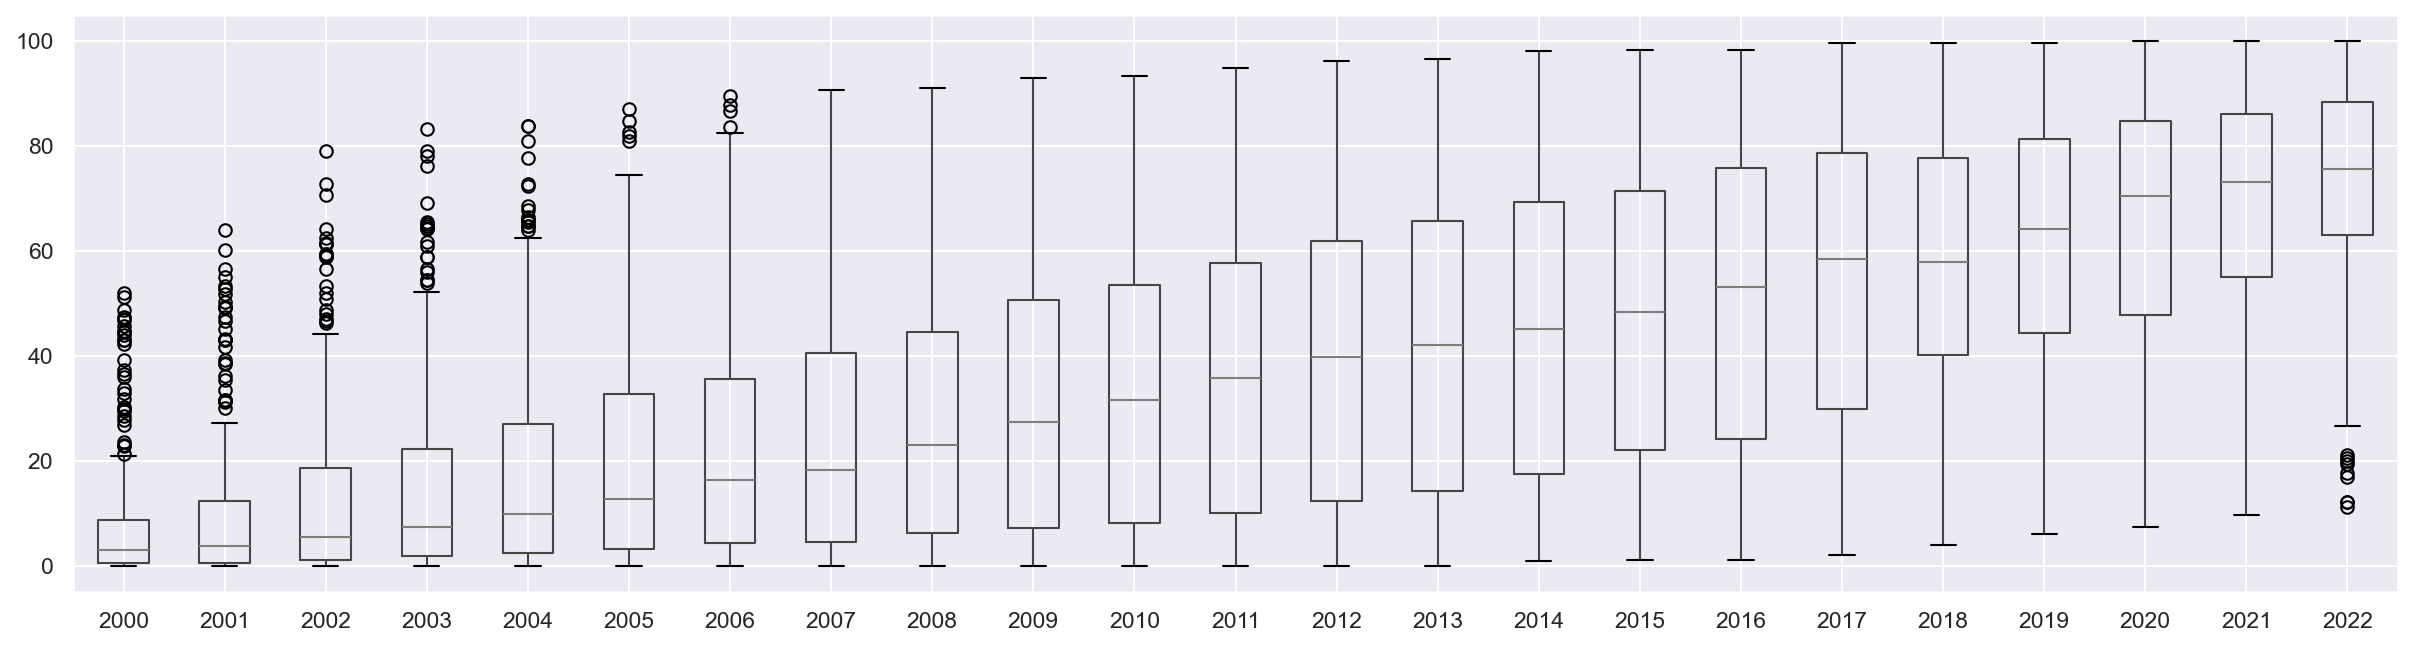

In [19]:
plt.figure(figsize=(20,5))
df.boxplot()
plt.show()

# Dropping Unnecessary Column

In [20]:
df.head()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Afghanistan,AFG,8.732304,0.004723,0.004561,0.087891,0.105809,1.22415,2.10712,1.90000,...,5.9,7.0000,8.26,11.0000,13.5000,16.800000,17.6000,18.4000,67.88072,71.291703
1,Albania,ALB,0.114097,0.325798,0.390081,0.971900,2.420390,6.04389,9.60999,15.03610,...,51.8,54.3000,56.90,59.6000,62.4000,65.400000,68.5504,72.2377,79.32370,82.613700
2,Algeria,DZA,0.491706,0.646114,1.591640,2.195360,4.634480,5.84394,7.37598,9.45119,...,22.5,29.5000,38.20,42.9455,47.6911,49.038500,58.9776,60.6534,66.23560,71.243200
4,Andorra,AND,10.538800,10.653857,11.260500,13.546400,26.838000,37.60580,48.93680,70.87000,...,84.4,86.1000,87.90,89.7000,91.5675,57.863789,90.7187,93.2056,93.89750,94.485500
5,Angola,AGO,0.105046,0.136014,0.270377,0.370682,0.464815,1.14337,1.50000,1.70000,...,13.0,21.3623,22.00,23.2000,26.0000,29.000000,32.1294,36.6347,37.80670,39.293500


In [21]:
df['Country Name'].value_counts()

Country Name
Afghanistan           1
Russian Federation    1
Namibia               1
Nauru                 1
Nepal                 1
                     ..
Gibraltar             1
Greece                1
Greenland             1
Grenada               1
Zimbabwe              1
Name: count, Length: 210, dtype: int64

In [22]:
df.drop(columns=['Country Name','Country Code'],inplace=True)

In [23]:
df.head()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,8.732304,0.004723,0.004561,0.087891,0.105809,1.22415,2.10712,1.90000,1.84,3.55,...,5.9,7.0000,8.26,11.0000,13.5000,16.800000,17.6000,18.4000,67.88072,71.291703
1,0.114097,0.325798,0.390081,0.971900,2.420390,6.04389,9.60999,15.03610,23.86,41.20,...,51.8,54.3000,56.90,59.6000,62.4000,65.400000,68.5504,72.2377,79.32370,82.613700
2,0.491706,0.646114,1.591640,2.195360,4.634480,5.84394,7.37598,9.45119,10.18,11.23,...,22.5,29.5000,38.20,42.9455,47.6911,49.038500,58.9776,60.6534,66.23560,71.243200
4,10.538800,10.653857,11.260500,13.546400,26.838000,37.60580,48.93680,70.87000,70.04,78.53,...,84.4,86.1000,87.90,89.7000,91.5675,57.863789,90.7187,93.2056,93.89750,94.485500
5,0.105046,0.136014,0.270377,0.370682,0.464815,1.14337,1.50000,1.70000,1.90,2.30,...,13.0,21.3623,22.00,23.2000,26.0000,29.000000,32.1294,36.6347,37.80670,39.293500


# Scaling

In [24]:
si=StandardScaler()
scaled_data=si.fit_transform(df)
scaled_data

array([[ 1.38380592e-16, -7.08504733e-01, -7.58089338e-01, ...,
        -1.84465564e+00,  5.87522795e-16,  6.28584723e-16],
       [-6.71369976e-01, -6.87143048e-01, -7.36620388e-01, ...,
         3.09977002e-01,  4.73089864e-01,  5.00802683e-01],
       [-6.41953726e-01, -6.65831888e-01, -6.69707552e-01, ...,
        -1.53636988e-01, -6.80146114e-02, -2.14543183e-03],
       ...,
       [-6.73831393e-01, -7.02777692e-01, -7.29452462e-01, ...,
        -2.02814341e+00, -2.19088669e+00, -2.37073668e+00],
       [-6.65373519e-01, -6.93308405e-01, -7.31738191e-01, ...,
        -1.60056023e+00, -1.69218798e+00, -1.77185223e+00],
       [-6.48986036e-01, -6.55603841e-01, -6.97086171e-01, ...,
        -1.40848397e+00, -1.46434124e+00, -1.71314214e+00]],
      shape=(210, 23))

# Model Building

In [25]:
km=KMeans()
y_pred=km.fit_predict(scaled_data)
y_pred

array([4, 3, 7, 1, 4, 5, 5, 3, 1, 6, 6, 5, 5, 1, 4, 1, 5, 6, 3, 4, 2, 3,
       3, 5, 3, 5, 5, 1, 5, 4, 4, 3, 7, 4, 2, 1, 4, 4, 1, 3, 3, 4, 4, 0,
       5, 7, 1, 3, 3, 1, 1, 2, 7, 5, 3, 3, 3, 7, 7, 4, 6, 7, 4, 2, 3, 2,
       6, 5, 3, 7, 3, 2, 7, 1, 5, 6, 3, 1, 7, 4, 4, 3, 7, 7, 6, 1, 2, 7,
       7, 3, 7, 6, 1, 1, 3, 2, 3, 5, 4, 7, 7, 2, 5, 1, 3, 7, 1, 5, 7, 4,
       3, 2, 1, 2, 1, 4, 4, 6, 3, 4, 1, 7, 7, 3, 3, 7, 3, 2, 7, 5, 5, 4,
       7, 7, 5, 7, 2, 5, 2, 7, 0, 4, 5, 2, 5, 4, 3, 3, 0, 3, 3, 7, 1, 1,
       5, 1, 5, 5, 4, 7, 6, 7, 5, 7, 5, 5, 4, 6, 6, 6, 4, 0, 3, 4, 1, 7,
       1, 5, 3, 4, 3, 2, 2, 7, 0, 4, 3, 4, 4, 3, 5, 3, 5, 7, 3, 4, 3, 6,
       2, 2, 5, 3, 7, 3, 3, 5, 3, 0, 4, 4], dtype=int32)

In [26]:
print(f'Cluster Center: {km.cluster_centers_}')
print('*'*100)
print(f'Inertia: {km.inertia_}')

Cluster Center: [[-6.66638988e-01 -6.94818303e-01 -7.37033885e-01 -7.95747005e-01
  -8.38881750e-01 -8.85977725e-01 -9.25451020e-01 -9.06327035e-01
  -9.56977645e-01 -1.00139715e+00 -8.71613111e-01 -1.11871304e+00
  -1.15484902e+00 -1.17817994e+00 -1.25469099e+00 -1.33256811e+00
  -1.41409050e+00 -1.48044471e+00  0.00000000e+00 -5.73909674e-01
  -1.78435016e+00 -1.86320567e+00 -1.96240899e+00]
 [ 2.00384461e-01  2.79913014e-01  3.79038888e-01  4.95475415e-01
   5.68295257e-01  6.52698441e-01  7.41854403e-01  8.42428909e-01
   9.27236486e-01  9.82532981e-01  1.00614835e+00  1.00024554e+00
   9.85679125e-01  9.51140178e-01  9.43366244e-01  9.55346720e-01
   1.02649565e+00  9.35860603e-01  8.16941518e-01  7.90196966e-01
   7.35629544e-01  6.95611396e-01  6.86111784e-01]
 [ 2.43827534e+00  2.43274961e+00  2.51068669e+00  2.44026849e+00
   2.36952716e+00  2.28263694e+00  2.19431413e+00  2.07720093e+00
   1.99523753e+00  1.91844436e+00  1.84285147e+00  1.76028668e+00
   1.69750582e+00  1.658

# Elbow Method

In [27]:
wcss=[]
for i in range(2,20):
    km=KMeans(n_clusters=i,random_state=0)
    km.fit_predict(scaled_data)
    wcss.append(km.inertia_)

In [28]:
wcss

[1975.435467079249,
 1109.412744579161,
 756.5341947685943,
 611.7172630331963,
 566.9802352495452,
 502.6830094374265,
 469.6520877025041,
 455.22383019988115,
 440.5844759258002,
 427.1837789171588,
 396.5035027767842,
 367.9697558708424,
 355.5942538304564,
 339.825866861064,
 323.3027957703997,
 311.50083510750625,
 300.8991353052599,
 299.40438404373583]

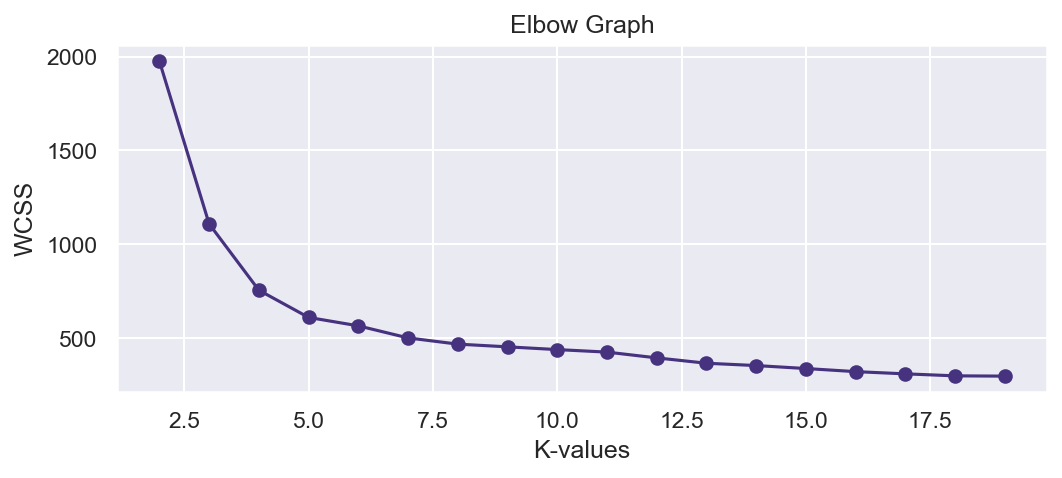

In [29]:
plt.plot(range(2,20),wcss,marker='o')
plt.xlabel('K-values')
plt.ylabel('WCSS')
plt.title('Elbow Graph')
plt.show()

# Final Model Building

In [30]:
km=KMeans(n_clusters=4,random_state=1)
y_pred=km.fit_predict(scaled_data)
y_pred

array([0, 1, 1, 3, 0, 3, 3, 1, 3, 2, 2, 1, 3, 3, 0, 3, 1, 2, 1, 0, 2, 1,
       1, 1, 1, 1, 1, 3, 1, 0, 0, 1, 0, 0, 2, 3, 0, 0, 3, 1, 1, 0, 0, 0,
       1, 0, 3, 1, 1, 3, 3, 2, 0, 3, 1, 1, 1, 0, 0, 0, 2, 0, 0, 2, 1, 2,
       3, 1, 1, 0, 1, 2, 0, 3, 3, 2, 1, 3, 0, 0, 0, 1, 0, 0, 2, 3, 2, 0,
       0, 1, 0, 3, 3, 3, 1, 2, 1, 1, 0, 0, 1, 2, 1, 3, 1, 0, 3, 3, 0, 0,
       1, 2, 3, 2, 3, 0, 0, 3, 1, 0, 3, 1, 0, 1, 1, 0, 1, 2, 1, 3, 1, 0,
       0, 0, 1, 0, 2, 3, 2, 0, 0, 0, 3, 2, 1, 0, 1, 1, 0, 1, 1, 1, 3, 3,
       3, 3, 1, 3, 0, 1, 2, 0, 3, 0, 3, 3, 0, 2, 3, 3, 0, 0, 1, 0, 3, 0,
       3, 1, 1, 0, 1, 2, 2, 0, 0, 0, 1, 0, 0, 1, 3, 1, 1, 0, 1, 0, 1, 3,
       2, 2, 3, 1, 0, 1, 1, 1, 1, 0, 0, 0], dtype=int32)

In [31]:
print(f'Cluster Center: {km.cluster_centers_}')
print('*'*100)
print(f'Inertia: {km.inertia_}')

Cluster Center: [[-0.58678315 -0.64520892 -0.69452488 -0.7283102  -0.76697957 -0.79421095
  -0.8166416  -0.88110814 -0.91259561 -0.96013816 -0.99484909 -1.04235944
  -1.067719   -1.09585969 -1.14365457 -1.1653575  -1.1882911  -1.19764963
  -1.13191285 -1.18633202 -1.2229397  -1.19989227 -1.1635315 ]
 [-0.44590432 -0.43927479 -0.40700244 -0.40088062 -0.39916616 -0.40352118
  -0.40049686 -0.36597363 -0.33622272 -0.27562444 -0.23145531 -0.18039726
  -0.14728765 -0.09695822 -0.02812184  0.01493845  0.06165158  0.11254743
   0.16892509  0.23007897  0.31922726  0.33113535  0.31954046]
 [ 2.33041183  2.29250371  2.20848834  2.16266417  2.11759048  2.09903556
   2.01428707  1.9278137   1.84754207  1.76931254  1.66695651  1.61128336
   1.52341736  1.49339936  1.42840699  1.39451422  1.32733311  1.26701222
   1.06034413  1.07010332  1.01873741  0.96784606  0.92238653]
 [ 0.15835122  0.25645163  0.33111053  0.39830793  0.47852724  0.53537265
   0.61267679  0.70778138  0.75771028  0.7860624   0.83

# Analyse The Cluster

In [32]:
df['Cluster']=y_pred
df.head()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Cluster
0,8.732304,0.004723,0.004561,0.087891,0.105809,1.22415,2.10712,1.90000,1.84,3.55,...,7.0000,8.26,11.0000,13.5000,16.800000,17.6000,18.4000,67.88072,71.291703,0
1,0.114097,0.325798,0.390081,0.971900,2.420390,6.04389,9.60999,15.03610,23.86,41.20,...,54.3000,56.90,59.6000,62.4000,65.400000,68.5504,72.2377,79.32370,82.613700,1
2,0.491706,0.646114,1.591640,2.195360,4.634480,5.84394,7.37598,9.45119,10.18,11.23,...,29.5000,38.20,42.9455,47.6911,49.038500,58.9776,60.6534,66.23560,71.243200,1
4,10.538800,10.653857,11.260500,13.546400,26.838000,37.60580,48.93680,70.87000,70.04,78.53,...,86.1000,87.90,89.7000,91.5675,57.863789,90.7187,93.2056,93.89750,94.485500,3
5,0.105046,0.136014,0.270377,0.370682,0.464815,1.14337,1.50000,1.70000,1.90,2.30,...,21.3623,22.00,23.2000,26.0000,29.000000,32.1294,36.6347,37.80670,39.293500,0


In [33]:
df.groupby('Cluster').mean()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.199917,0.956086,1.145993,1.828166,2.316923,3.024668,4.245626,3.672602,4.970010,5.771129,...,10.749567,12.588717,15.183256,17.866069,21.331784,29.975808,31.652646,33.934786,38.858026,44.986932
1,3.008343,4.051366,6.309056,8.248051,10.087358,11.768301,13.996128,16.490589,19.839387,23.927291,...,39.361119,44.408854,48.455735,53.128941,57.797373,62.025752,66.990490,72.468836,75.890140,78.515778
2,38.647215,45.111185,53.275627,58.511266,63.256417,67.775493,70.575856,73.566433,76.176567,78.167559,...,84.913759,85.955771,87.345901,88.835832,89.928600,83.988464,87.948142,89.947461,91.290739,92.144741
3,10.765019,14.508437,19.563408,23.917676,28.629529,32.780734,37.735349,43.208617,48.060879,52.087660,...,67.605434,70.840283,73.079832,76.614078,78.877607,77.864913,81.182209,83.359437,85.622515,87.631792


# Evaluation

In [34]:
silhouette_score(scaled_data,y_pred)

0.42605072071553324

# Conclusion

The K-Means clustering model was applied to the Internet Usage dataset with **4 clusters (K=4)**. The model achieved a **Silhouette Score of 0.4261**, which indicates a **moderate clustering quality**.

* A silhouette score ranges from **-1 to 1**.
* Values closer to **1** indicate well-separated and distinct clusters.
* Values around **0.4–0.5** suggest that the clusters are reasonably formed but there is some overlap between them.
* Since the score is **0.426**, the clustering structure is acceptable and meaningful, though not perfectly separated.

Based on the cluster means:

* **Cluster 0** represents countries/regions with **very low internet usage** over the years.
* **Cluster 1** represents **low to moderate internet usage** growth.
* **Cluster 3** represents **moderate to high internet usage** with steady growth.
* **Cluster 2** represents countries/regions with **consistently high internet usage**, showing the highest average values across all years.

Overall, the K-Means model successfully segmented the data into groups with different internet usage patterns and adoption levels. The silhouette score indicates that the clusters are reasonably distinct and can be used for further analysis and interpretation.

**Result:**
**K = 4**
**Silhouette Score = 0.4261**
**Interpretation: Moderate clustering performance with meaningful segmentation of internet usage patterns.**
